# Solutions to Process 6
Investigate the validity of the proposed $\{PPB, \tau_\alpha\}$ system solved for $\{T_e, n_e\}$. Now that n_alpha / n_e is being calculated (rather than fixed), are the solutions still valid?

In [1]:
# Reload Process each time (keep editable install up-to-date)
%load_ext autoreload
%autoreload 2
from IPython.display import clear_output
import process
from process.main import SingleRun
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Running scipy's SLSQP


## Set up
Same as in `solutions_to_process_2.ipynb`.

Checkout commit before f_nd_alpha_electron was changed to an output (cd5f6d0881de7ea451425d5fac6a6ee2a0834e6c).

## Check before and after n_alpha/n_e calculation
Currently, the plasma current is fixed, which needs to change. Run as before, but include plasma current.

In [2]:
w_fracs = np.linspace(5.0e-6, 1.0e-4, 20)
sol_data = {
    "w": [],
    "tau_e_scaling_hfact": [],
    "te": [],
    "ne": [],
    "pfus": [],
    "he": [],
    "ploss": [],
    "nd_alphas": [],
    "f_nd_alpha_electron": [],
    "ip": [],
}
for w_frac in w_fracs:
    # Solve Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_IN.DAT")
    process.fortran.impurity_radiation_module.impurity_arr_frac[13] = w_frac
    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        continue
    sol_data["w"].append(w_frac)
    sol_data["tau_e_scaling_hfact"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )
    sol_data["te"].append(process.fortran.physics_variables.te.item())
    sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["pfus"].append(process.fortran.physics_variables.p_fusion_total_mw.item())
    sol_data["he"].append(process.fortran.physics_variables.fusden_plasma_alpha.item())
    sol_data["ploss"].append(process.fortran.physics_variables.p_plasma_loss_mw.item())
    sol_data["nd_alphas"].append(process.fortran.physics_variables.nd_alphas.item())
    sol_data["f_nd_alpha_electron"].append(
        process.fortran.physics_variables.f_nd_alpha_electron.item()
    )
    sol_data["ip"].append(process.fortran.physics_variables.plasma_current.item())

# Clear the lengthy stdout from multiple process runs
clear_output()

Text(0.5, 0.98, 'Various quantities against W density fraction for $\\{PPB, \\tau_\\alpha\\}$ equations solved for $\\{T_e, n_e\\}$')

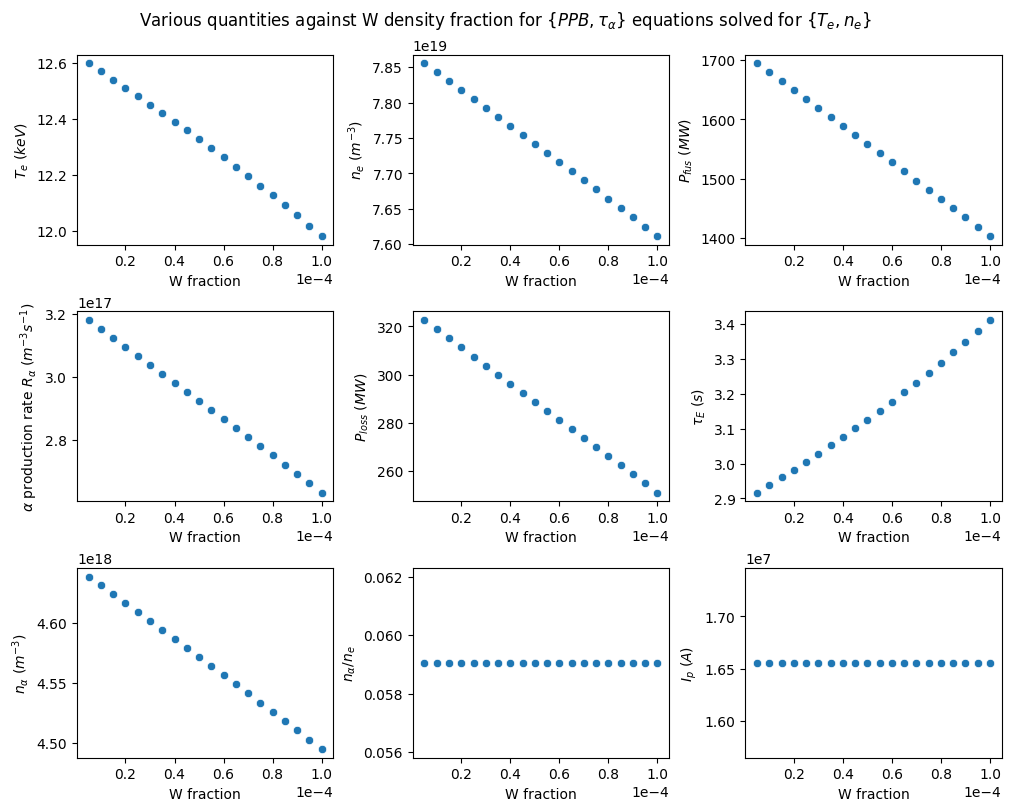

In [6]:
# Plot
sol_df = pd.DataFrame(sol_data)
fig, ax = plt.subplots(ncols=3, nrows=3, layout="constrained")
fig.set_size_inches(10, 8)

# te plot
ax0 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="te",
    ax=ax[0, 0],
)
ax0.set_xlabel("W fraction")
ax0.set_ylabel(r"$T_e$ $(keV)$")
ax0.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# ne plot
ax1 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="ne",
    ax=ax[0, 1],
)
ax1.set_xlabel("W fraction")
ax1.set_ylabel(r"$n_e$ $(m^{-3})$")
ax1.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# pfus plot
ax2 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="pfus",
    ax=ax[0, 2],
)
ax2.set_xlabel("W fraction")
ax2.set_ylabel(r"$P_{fus}$ $(MW)$")
ax2.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# alpha plot
ax3 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="he",
    ax=ax[1, 0],
)
ax3.set_xlabel("W fraction")
ax3.set_ylabel(r"$\alpha$ production rate $R_{\alpha}$ $(m^{-3}s^{-1})$")
ax3.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# ploss plot
ax4 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="ploss",
    ax=ax[1, 1],
)
ax4.set_xlabel("W fraction")
ax4.set_ylabel(r"$P_{loss}$ $(MW)$")
ax4.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# tau_E plot
ax5 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="tau_e_scaling_hfact",
    ax=ax[1, 2],
)
ax5.set_xlabel("W fraction")
ax5.set_ylabel(r"$\tau_E$ $(s)$")
ax5.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# nd_alphas plot
ax6 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="nd_alphas",
    ax=ax[2, 0],
)
ax6.set_xlabel("W fraction")
ax6.set_ylabel(r"$n_{\alpha}$ $(m^{-3})$")
ax6.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# f_nd_alpha_electron plot
ax7 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="f_nd_alpha_electron",
    ax=ax[2, 1],
)
ax7.set_xlabel("W fraction")
ax7.set_ylabel(r"$n_{\alpha}/n_{e}$")
ax7.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# plasma current plot
ax8 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="ip",
    ax=ax[2, 2],
)
ax8.set_xlabel("W fraction")
ax8.set_ylabel(r"$I_p$ $(A)$")
ax8.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

fig.suptitle(
    r"Various quantities against W density fraction for $\{PPB, \tau_\alpha\}$ equations solved for $\{T_e, n_e\}$"
)

ne decreases with W fraction.

Now install commit with calculated alpha fraction (ec78badb16beac41b49480201841ccc98dd7b8bd).

In [5]:
w_fracs = np.linspace(5.0e-6, 1.0e-4, 20)
sol_data = {
    "w": [],
    "tau_e_scaling_hfact": [],
    "te": [],
    "ne": [],
    "pfus": [],
    "he": [],
    "ploss": [],
    "nd_alphas": [],
    "f_nd_alpha_electron": [],
    "ip": [],
    "eta_cd_hcd_primary": [],
    "eta_cd_hcd_secondary": [],
}
for w_frac in w_fracs:
    # Solve Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_IN.DAT")
    process.fortran.impurity_radiation_module.impurity_arr_frac[13] = w_frac
    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        continue
    sol_data["w"].append(w_frac)
    sol_data["tau_e_scaling_hfact"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )
    sol_data["te"].append(process.fortran.physics_variables.te.item())
    sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["pfus"].append(process.fortran.physics_variables.p_fusion_total_mw.item())
    sol_data["he"].append(process.fortran.physics_variables.fusden_plasma_alpha.item())
    sol_data["ploss"].append(process.fortran.physics_variables.p_plasma_loss_mw.item())
    sol_data["nd_alphas"].append(process.fortran.physics_variables.nd_alphas.item())
    sol_data["f_nd_alpha_electron"].append(
        process.fortran.physics_variables.f_nd_alpha_electron.item()
    )
    sol_data["ip"].append(process.fortran.physics_variables.plasma_current.item())
    sol_data["eta_cd_hcd_primary"].append(
        process.fortran.current_drive_variables.eta_cd_hcd_primary.item()
    )
    sol_data["eta_cd_hcd_secondary"].append(
        process.fortran.current_drive_variables.eta_cd_hcd_secondary.item()
    )

# Clear the lengthy stdout from multiple process runs
clear_output()

Text(0.5, 0.98, 'Various quantities against W density fraction for $\\{PPB, \\tau_\\alpha\\}$ equations solved for $\\{T_e, n_e\\}$')

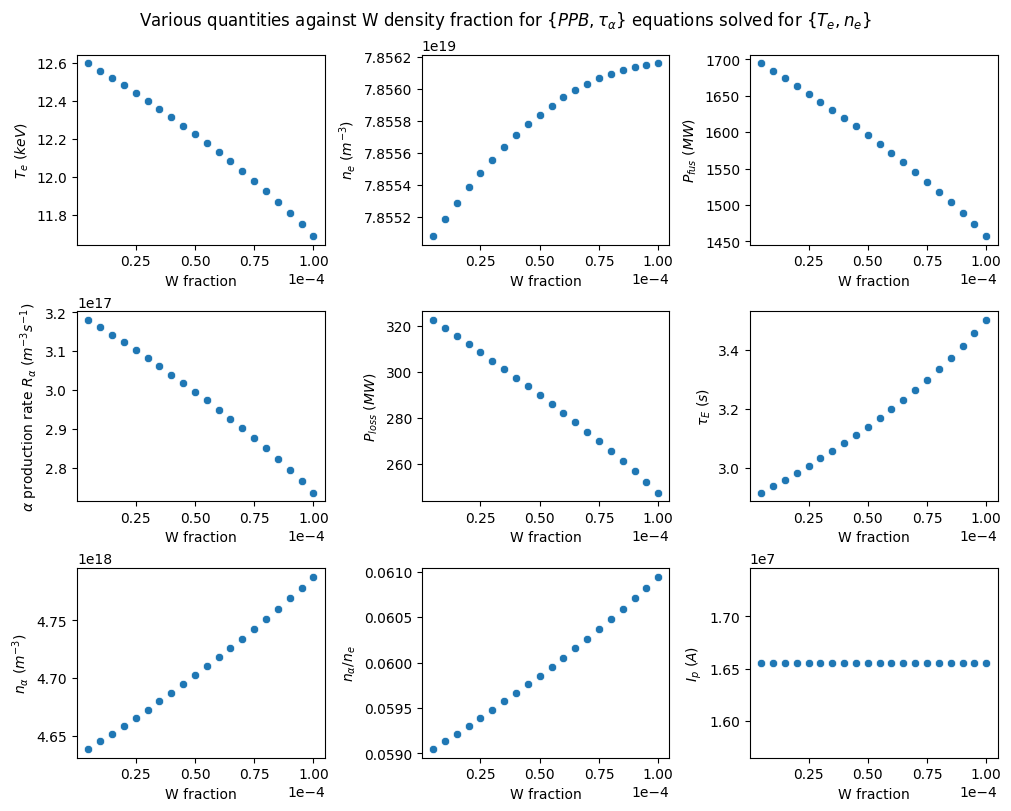

In [3]:
# Plot
sol_df = pd.DataFrame(sol_data)
fig, ax = plt.subplots(ncols=3, nrows=3, layout="constrained")
fig.set_size_inches(10, 8)

# te plot
ax0 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="te",
    ax=ax[0, 0],
)
ax0.set_xlabel("W fraction")
ax0.set_ylabel(r"$T_e$ $(keV)$")
ax0.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# ne plot
ax1 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="ne",
    ax=ax[0, 1],
)
ax1.set_xlabel("W fraction")
ax1.set_ylabel(r"$n_e$ $(m^{-3})$")
ax1.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# pfus plot
ax2 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="pfus",
    ax=ax[0, 2],
)
ax2.set_xlabel("W fraction")
ax2.set_ylabel(r"$P_{fus}$ $(MW)$")
ax2.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# alpha plot
ax3 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="he",
    ax=ax[1, 0],
)
ax3.set_xlabel("W fraction")
ax3.set_ylabel(r"$\alpha$ production rate $R_{\alpha}$ $(m^{-3}s^{-1})$")
ax3.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# ploss plot
ax4 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="ploss",
    ax=ax[1, 1],
)
ax4.set_xlabel("W fraction")
ax4.set_ylabel(r"$P_{loss}$ $(MW)$")
ax4.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# tau_E plot
ax5 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="tau_e_scaling_hfact",
    ax=ax[1, 2],
)
ax5.set_xlabel("W fraction")
ax5.set_ylabel(r"$\tau_E$ $(s)$")
ax5.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# nd_alphas plot
ax6 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="nd_alphas",
    ax=ax[2, 0],
)
ax6.set_xlabel("W fraction")
ax6.set_ylabel(r"$n_{\alpha}$ $(m^{-3})$")
ax6.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# f_nd_alpha_electron plot
ax7 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="f_nd_alpha_electron",
    ax=ax[2, 1],
)
ax7.set_xlabel("W fraction")
ax7.set_ylabel(r"$n_{\alpha}/n_{e}$")
ax7.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# plasma current plot
ax8 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="ip",
    ax=ax[2, 2],
)
ax8.set_xlabel("W fraction")
ax8.set_ylabel(r"$I_p$ $(A)$")
ax8.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

fig.suptitle(
    r"Various quantities against W density fraction for $\{PPB, \tau_\alpha\}$ equations solved for $\{T_e, n_e\}$"
)

Text(0.5, 0.98, 'HCD efficiencies against W density fraction for $\\{PPB, \\tau_\\alpha\\}$ equations solved for $\\{T_e, n_e\\}$')

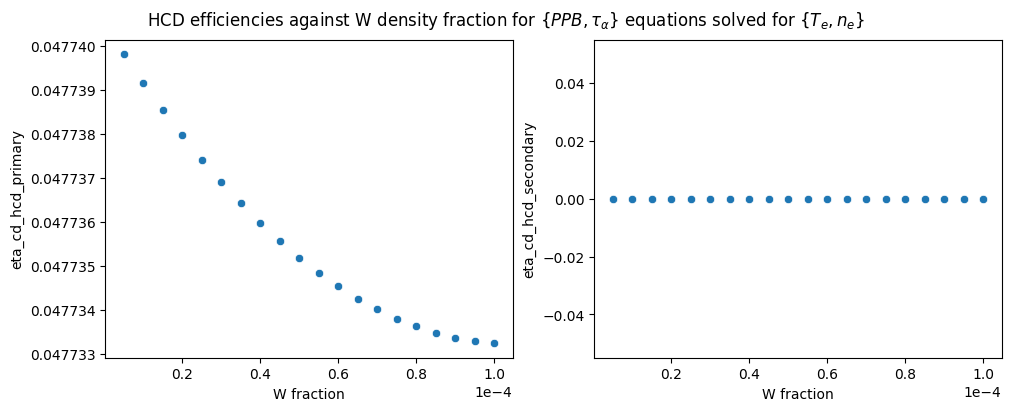

In [15]:
# Plot
sol_df = pd.DataFrame(sol_data)
fig, ax = plt.subplots(ncols=2, layout="constrained")
fig.set_size_inches(10, 4)

# eta_cd_hcd_primary plot
ax0 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="eta_cd_hcd_primary",
    ax=ax[0],
)
ax0.set_xlabel("W fraction")
ax0.set_ylabel(r"eta_cd_hcd_primary")
ax0.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# eta_cd_hcd_secondary plot
ax1 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="eta_cd_hcd_secondary",
    ax=ax[1],
)
ax1.set_xlabel("W fraction")
ax1.set_ylabel(r"eta_cd_hcd_secondary")
ax1.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

fig.suptitle(
    r"HCD efficiencies against W density fraction for $\{PPB, \tau_\alpha\}$ equations solved for $\{T_e, n_e\}$"
)